# Quick Start. Actions calculation

The package allows finding actions, angles and frequencies on the different time scales. These quantities can be computed either directly from the phase-space trajectories (and instantaneous actions) of N-body particles or by integrating test orbits within a potential of the individual N-body snapshot with a specified pattern speed.

In [43]:
import numpy as np
import matplotlib.pyplot as plt

import galport
import agama

Load coordinates, velocities and actions for the set of orbits

In [44]:
xv_act = np.load('data/xv_act_0.npy')

t = np.arange(0, 600.125, 0.125)
xv = xv_act[:,:,0:6]
act = xv_act[:,:,6:9]

Find actions, angles and frequencies on the different time scales of the orbit

In [45]:
num = 7

data = galport.averager.action(
    t, xv[num], act=act[num], secular=True, secular_extrema=True)

# Avaraged variables
JR = data[:,0]
Jz = data[:,1]
Lz = data[:,2]

kappa = data[:,6]
omegaz = data[:,7]
Omega = data[:,8]

# Secular variables
JR_sec = data[:,9]
Jz_sec = data[:,10]
Lz_sec = data[:,11]

kappa_sec = data[:,12]
omegaz_sec = data[:,13]
Omega_sec = data[:,14]

# Extrema
JR_max = data[:,15]
Jz_max = data[:,16]
Lz_max = data[:,17]

JR_min = data[:,21]
Jz_min = data[:,22]
Lz_min = data[:,23]

Plot actions

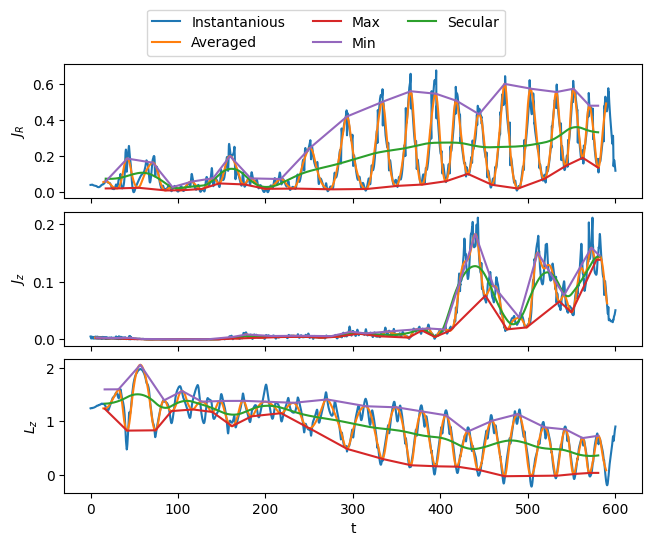

In [46]:
fig, axes = plt.subplots(3, sharex=True, constrained_layout=True)

# JR
line0, = axes[0].plot(t, act[num,:,0], label='Instantanious')
line1, = axes[0].plot(t, JR, label='Averaged')
line2, = axes[0].plot(t, JR_sec, label='Secular')
line3, = axes[0].plot(t, JR_max, label='Max')
line4, = axes[0].plot(t, JR_min, label='Min')

axes[0].set_ylabel('$J_R$')

# Jz
axes[1].plot(t, act[num,:,1])
axes[1].plot(t, Jz)
axes[1].plot(t, Jz_sec)
axes[1].plot(t, Jz_max)
axes[1].plot(t, Jz_min)

axes[1].set_ylabel('$J_z$')

# Lz
axes[2].plot(t, act[num,:,2])
axes[2].plot(t, Lz)
axes[2].plot(t, Lz_sec)
axes[2].plot(t, Lz_max)
axes[2].plot(t, Lz_min)
axes[2].set_ylabel('$L_z$')

axes[2].set_xlabel('t')


fig.legend(handles=[line0, line1, line3, line4, line2], loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 1.12))

plt.show()

Plot frequencies

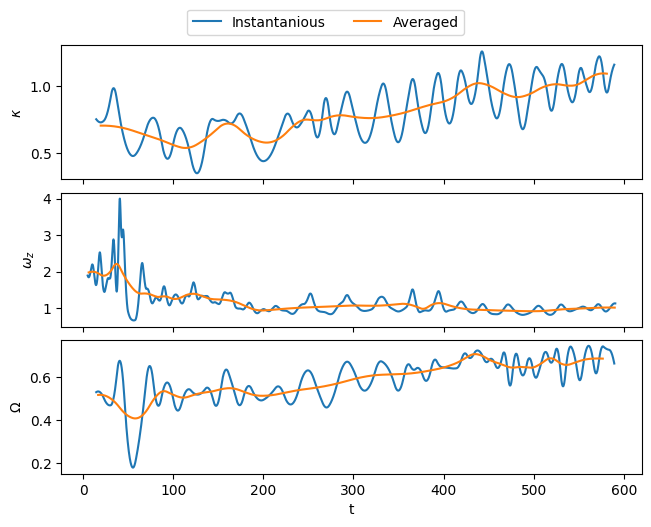

In [47]:
fig, axes = plt.subplots(3, sharex=True, constrained_layout=True)

line0, = axes[0].plot(t, kappa, label='Instantanious')
line1, = axes[0].plot(t, kappa_sec, label='Averaged')

axes[0].set_ylabel('$\\kappa$')


axes[1].plot(t, omegaz)
axes[1].plot(t, omegaz_sec)
axes[1].set_ylabel('$\\omega_z$')

axes[2].plot(t, Omega)
axes[2].plot(t, Omega_sec)
axes[2].set_ylabel('$\\Omega$')

axes[2].set_xlabel('t')

fig.legend(handles=[line0, line1], loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 1.08))
plt.show()